<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/06_lognormal_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 6 — Lognormal regression

Replace the Gaussian likelihood with a lognormal likelihood, so reaction times are constrained to be positive and the model can represent right skew.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.

#### Format colors

In [4]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [5]:

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [6]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

## 6.1 Priors on the wrong scale

What goes wrong if Gaussian-scale priors are reused in a lognormal model?

For a lognormal likelihood, `mu` is the location parameter of **log reaction time**. An intercept around 250 is therefore astronomically large. This is exactly the sort of mistake prior predictive simulation should catch.

In [7]:
bad_coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=bad_coords) as bad_model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=20)
    sigma = pm.Exponential("sigma", lam=0.02)
    mu = pm.Deterministic("mu", intercept + slope * days, dims="obs_id")
    pm.LogNormal(
        "Reaction", mu=mu, sigma=sigma,
        observed=sleep["Reaction"].to_numpy(), dims="obs_id",
    )

    bad_prior = pm.sample_prior_predictive(
        draws=200, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

yrep = bad_prior["prior_predictive"]["Reaction"].to_numpy()
finite_fraction = np.isfinite(yrep).mean()
finite_values = yrep[np.isfinite(yrep) & (yrep > 0)]
print(f"Finite prior-predictive values: {finite_fraction:.1%}")
if finite_values.size:
    print("Finite log10 reaction-time range:", np.log10(finite_values).min(), "to", np.log10(finite_values).max())

Sampling: [Reaction, intercept, sigma, slope]


Finite prior-predictive values: 99.8%
Finite log10 reaction-time range: -302.59965639825253 to 307.34719489976595


## 6.2 Priors on the log scale

What prior assumptions make sense when the linear predictor is on the log reaction-time scale?

The chapter centres the intercept at 5 on the log scale (about 150 ms), with a wide SD of 0.55.

In [8]:
coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    intercept = pm.Normal("intercept", mu=5, sigma=0.55)
    slope = pm.Normal("slope", mu=0, sigma=0.20)
    sigma = pm.Exponential("sigma", lam=3)

    mu = pm.Deterministic("mu", intercept + slope * days, dims="obs_id")
    # Expected reaction time on the millisecond scale: for a lognormal
    # likelihood this is exp(mu + sigma^2 / 2), not mu itself.
    mean_rt = pm.Deterministic(
        "mean_rt", pm.math.exp(mu + sigma**2 / 2), dims="obs_id"
    )

    pm.LogNormal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior. The distribution is right-skewed, so the mean line can sit near or above the top of the 50% band.

Sampling: [Reaction, intercept, sigma, slope]


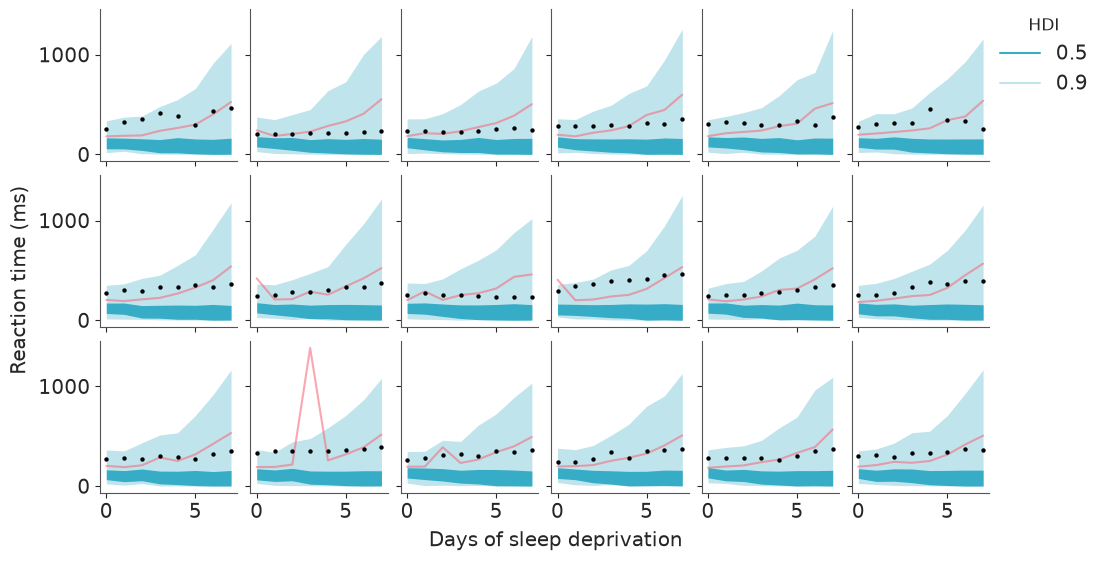

In [9]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 6.3 Population effect under a lognormal likelihood

What population-average deprivation effect is estimated under a positive, right-skewed likelihood?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [10]:
with model:
    idata = pm.sample(
        draws=1000, tune=1500, chains=4, target_accept=0.92, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(idata, var_names=["intercept", "slope", "sigma"], ci_prob=0.90, ci_kind="hdi", round_to=2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 8 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,5.59,0.03,5.55,5.63,1727.88,1709.81,1.0,0.0,0.0
slope,0.04,0.01,0.03,0.05,1745.75,1751.73,1.0,0.0,0.0
sigma,0.17,0.01,0.15,0.18,2532.99,2107.00,1.0,0.0,0.0


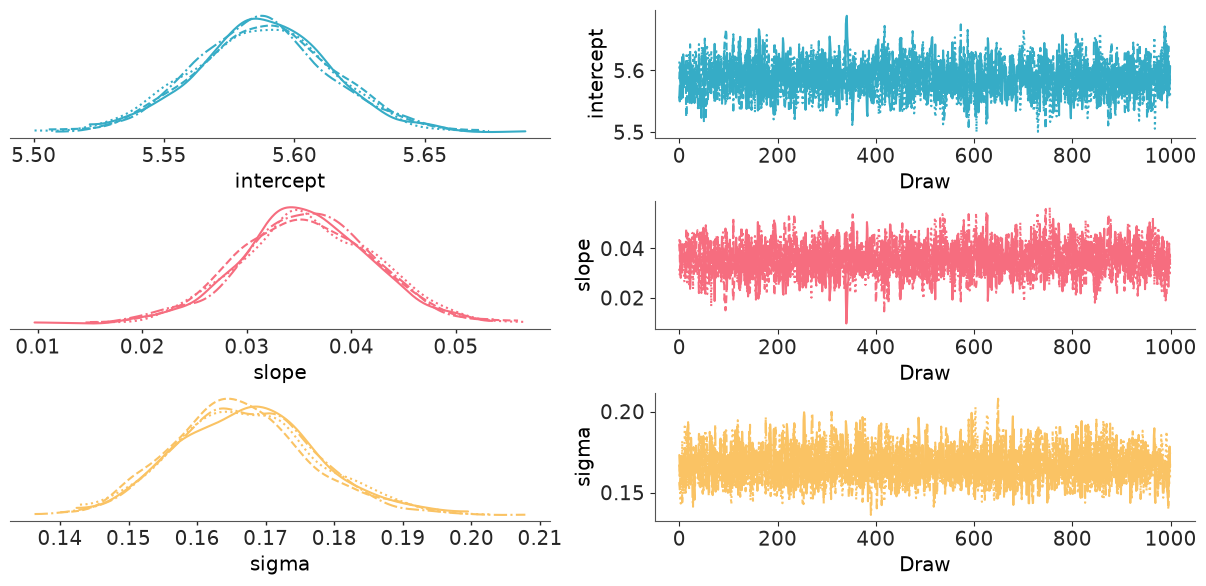

In [11]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "sigma"]);

This plot shows posterior uncertainty in the population-average expected reaction time on each day (on the millisecond scale). It does not include the variation of individual measurements.

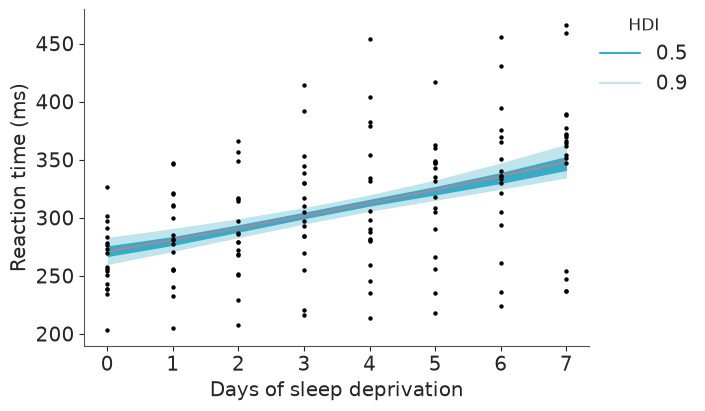

In [12]:
plot_population(idata, "mean_rt")
plt.show()

## 6.4 Predictive consequences of the likelihood

Does changing the likelihood to lognormal address the predictive problems of the Gaussian regression?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

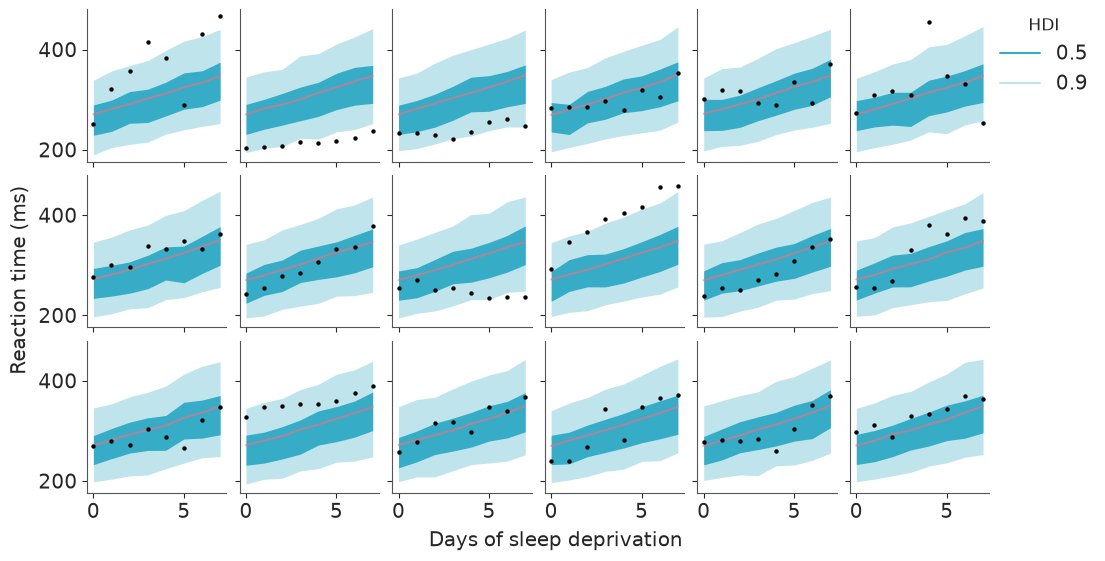

In [13]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The panel plot checks trajectories. This check pools all 144 measurements and asks whether simulated datasets reproduce the overall *shape* of the reaction-time distribution, especially its right tail.

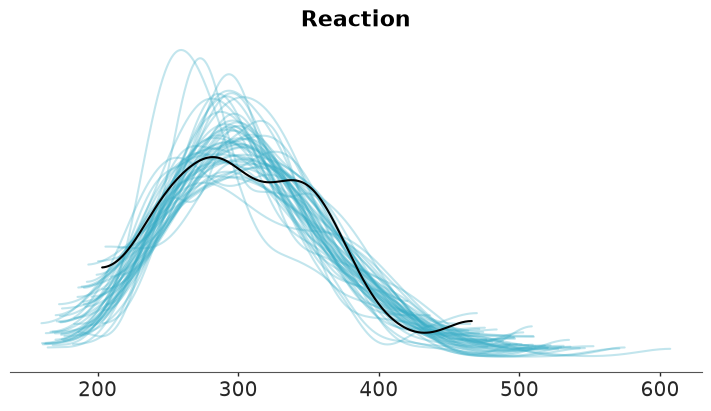

In [14]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

## 6.5 Sensitivity on a transformed scale

How sensitive is the lognormal fit to the priors chosen on the transformed parameter scale?

In [15]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(idata, model=model, kind="prior", extend_inferencedata=True)

azs.psense_summary(idata, var_names=["intercept", "slope", "sigma"])

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

,prior,likelihood,diagnosis
intercept,0.008,0.096,✓
slope,0.007,0.095,✓
sigma,0.005,0.123,✓


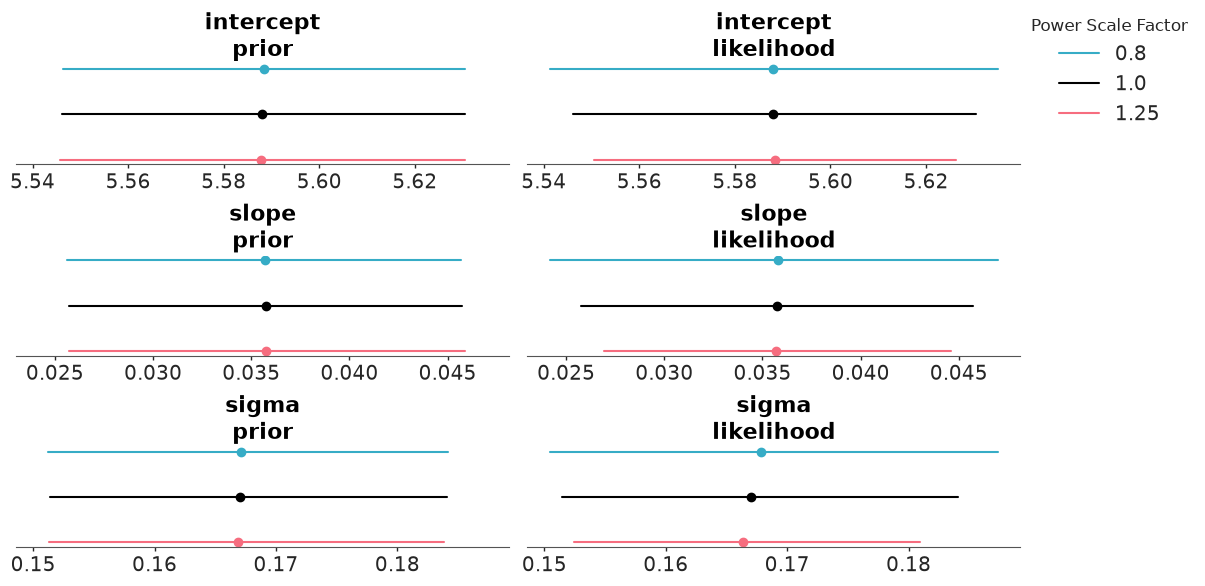

In [16]:
azp.plot_psense_dist(
    idata,
    var_names=["intercept", "slope", "sigma"],
    visuals={"dist": False},
);

A positive-only likelihood is scientifically attractive, but the main between-person structure is still missing. We next combine the lognormal response with varying participant intercepts and slopes.